In [8]:
import pandas as pd

df = pd.read_csv("../data/filteredvehpub.csv")
df.head()
df.shape

## read path file

(256115, 14)

In [10]:
df.columns
## features and targets

Index(['HOUSEID', 'HHFAMINC', 'HHSIZE', 'LIF_CYC', 'CENSUS_R', 'URBAN',
       'VEHID', 'DRVRCNT', 'MAKE', 'HH_RACE', 'WRKCOUNT', 'HOMEOWN',
       'URBANSIZE', 'VEHYEAR'],
      dtype='object')

In [12]:
import numpy as np
invalid_values = [-9, -8, -7, -88, 99, "99", "XX", "xx", "XX ", "-88", "-9", "-8", "-7"]
df = df.replace(invalid_values, np.nan)
df = df.dropna()
## cleaning NaN

In [14]:
counts = df["MAKE"].value_counts()
counts.describe()
## percentile of makes

count       53.000000
mean      4607.245283
std       8163.852477
min         58.000000
25%        286.000000
50%       1580.000000
75%       4639.000000
max      34768.000000
Name: count, dtype: float64

In [16]:
df["MAKE"] = df["MAKE"].astype(str)   # convert everything to string first
df["MAKE"] = df["MAKE"].str.strip()   # remove whitespace
df["MAKE"] = df["MAKE"].astype(int)   # convert to integer

## Did this because the original data has different variable types, wanted to convert to same type

counts = df["MAKE"].value_counts()
rare_makes = counts[counts < 1000].index
## The number of 1000 can be found in the report

df["MAKE"] = df["MAKE"].where(~df["MAKE"].isin(rare_makes), 98)
df["MAKE"].value_counts()
## Put them all into to other

MAKE
12    34768
49    33623
20    31188
37    23829
7     12545
35    11684
98     9164
2      7293
48     6932
23     6896
55     6765
59     4967
18     4852
6      4703
63     4639
30     4608
34     4536
41     4335
42     3642
72     3064
19     2664
22     2659
54     2536
51     1831
14     1798
13     1787
24     1580
32     1491
58     1416
52     1236
53     1153
Name: count, dtype: int64

In [18]:
#df.to_csv("processed_data.csv", index=False)

In [20]:
df.columns.tolist()

['HOUSEID',
 'HHFAMINC',
 'HHSIZE',
 'LIF_CYC',
 'CENSUS_R',
 'URBAN',
 'VEHID',
 'DRVRCNT',
 'MAKE',
 'HH_RACE',
 'WRKCOUNT',
 'HOMEOWN',
 'URBANSIZE',
 'VEHYEAR']

In [24]:
feature_cols = [
   "HHFAMINC",
    "HHSIZE",
    "LIF_CYC",
    "HHSTATES",
    "URBAN"
]
target_col = "MAKE"
X = df[feature_cols]
y = df[target_col]

KeyError: "['STATES'] not in index"

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["HHFAMINC", "LIF_CYC", "CENSUS_R", "URBAN"]
num_cols = ["HHSIZE"]   # only numeric column

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=3000,
    random_state=42,
    n_jobs=-1,           # use all CPU cores
    min_samples_split=10,
    min_samples_leaf=1
    
)

pipe = Pipeline([
    ("preprocess", preprocess),   # your ColumnTransformer from Step 7
    ("rf", rf)
])

pipe

,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(
    pipe,
    X, y,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

print("Cross-validated Top-1 Accuracy:", cv_acc.mean(), "+/-", cv_acc.std())

Cross-validated Top-1 Accuracy: 0.16559233509828317 +/- 0.0012104224637580327


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [15]:
from sklearn.metrics import accuracy_score

y_pred = pipe.predict(X_test)

test_acc = accuracy_score(y_test, y_pred)
print("Test Top-1 Accuracy:", test_acc)

Test Top-1 Accuracy: 0.16639023691053914


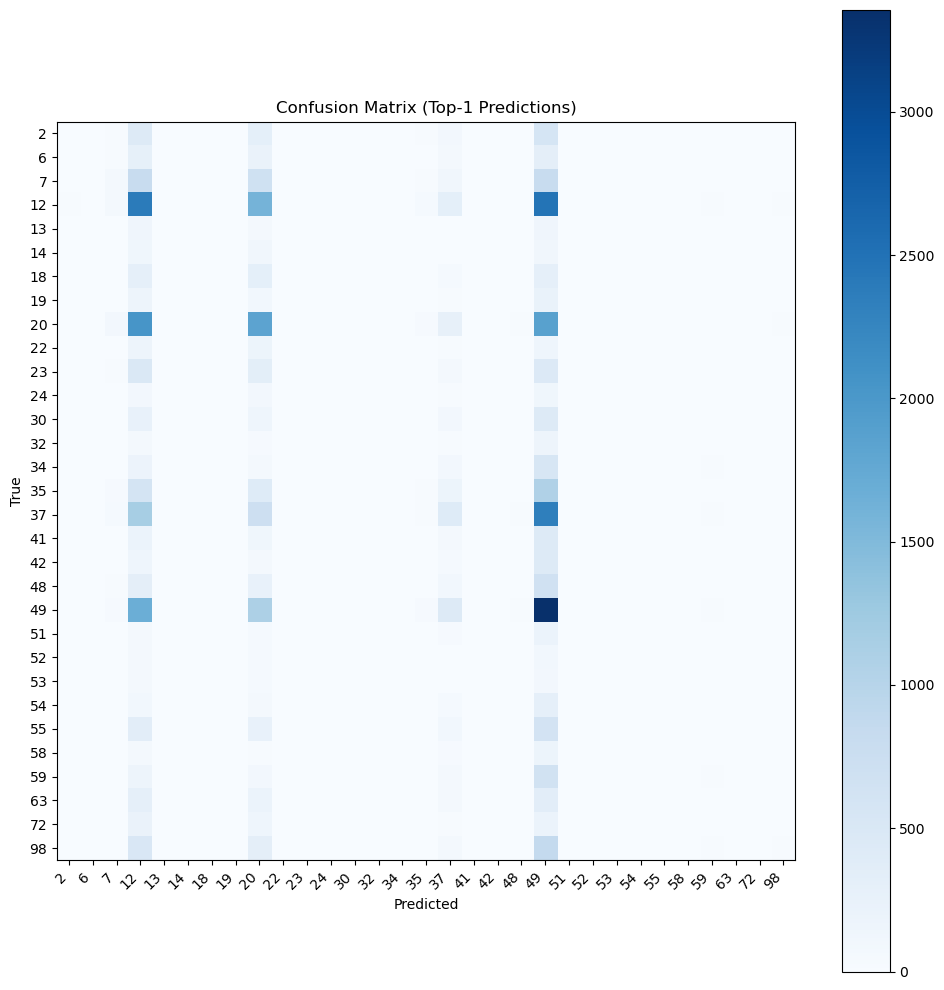

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

labels = sorted(y.unique())

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (Top-1 Predictions)")

plt.tight_layout()
plt.show()